# CNN group-aware con aumento exclusivo de entrenamiento

Tercera etapa. Mantiene la auditoría y el split por fuente, e incorpora perturbaciones espectrales moderadas únicamente durante el entrenamiento. Permite estudiar si la regularización mediante aumento de datos recupera capacidad de generalización sin contaminar validación ni prueba.

- Utiliza los datos y la CNN del Notebook 01.
- Verifica mejora de rendimiento mediante aumentación del training set.
  
## Lugar dentro de la progresión experimental

Este notebook se conserva como evidencia de desarrollo y comparación. Debe ejecutarse desde un kernel limpio para generar sus resultados; no contiene métricas heredadas. Su propósito es mostrar qué problema metodológico se identifica en esta etapa y cómo conduce al siguiente experimento. Los resultados finales del TFM proceden de los notebooks con split fijo y cinco semillas.


Este notebook lee los TXT directamente desde los ZIP y muestra resultados inline. No exporta archivos ni crea carpetas de resultados.

## Importaciones y reproducibilidad

Se cargan las bibliotecas necesarias y se fijan las semillas aleatorias disponibles. La celda también informa de las versiones principales y de la disponibilidad de GPU. Fijar semillas reduce variaciones accidentales, aunque una única ejecución todavía no permite medir toda la variabilidad del entrenamiento; esa limitación se resuelve posteriormente en los notebooks finales de cinco semillas.


In [1]:
import os, re, json, random, zipfile, platform, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from scipy.interpolate import interp1d
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    log_loss, accuracy_score, top_k_accuracy_score,
    precision_recall_fscore_support, classification_report,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("Python:", platform.python_version())
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Devices:", tf.config.list_physical_devices())
print("✓ Reproducibility configured")
# Modo solo pantalla: no se escriben resultados en disco.
def _mostrar_en_pantalla(obj, destino=None, *args, **kwargs):
    nombre = str(destino) if destino is not None else "salida tabular"
    print(f"\n[SOLO PANTALLA] {nombre} | dimensiones: {getattr(obj, 'shape', None)}")
    try:
        display(obj if len(obj) <= 40 else obj.head(40))
    except Exception:
        print(obj)

pd.DataFrame.to_csv = lambda self, path_or_buf=None, *a, **k: _mostrar_en_pantalla(self, path_or_buf)
pd.Series.to_csv = lambda self, path_or_buf=None, *a, **k: _mostrar_en_pantalla(self, path_or_buf)
np.save = lambda destino, datos, *a, **k: _mostrar_en_pantalla(pd.DataFrame(np.atleast_1d(datos)), destino)
plt.savefig = lambda destino, *a, **k: print(f"[SOLO PANTALLA] Figura mostrada; no se guarda {destino}")
from matplotlib.figure import Figure
Figure.savefig = lambda self, destino, *a, **k: print(f"[SOLO PANTALLA] Figura mostrada; no se guarda {destino}")
Path.write_text = lambda self, data, *a, **k: print(f"[SOLO PANTALLA] {self.name}:\n{str(data)[:4000]}") or len(str(data))

class ZipMember:
    """Referencia ligera a un TXT dentro de un ZIP, sin extracción a disco."""
    def __init__(self, archive_path, member):
        self.archive_path, self.member = Path(archive_path), member
    @property
    def name(self): return Path(self.member).name
    def read_bytes(self):
        with zipfile.ZipFile(self.archive_path) as zf: return zf.read(self.member)
    def __str__(self): return f"{self.archive_path.name}::{self.member}"
    def __repr__(self): return str(self)

def open_spectrum(member):
    import io
    return io.StringIO(member.read_bytes().decode("utf-8", errors="replace"))


Python: 3.11.15
TensorFlow: 2.21.0
NumPy: 2.4.6
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
✓ Reproducibility configured


## Configuración del experimento

Aquí se concentran las rutas, criterios mínimos de inclusión, tamaño de la cuadrícula Raman y parámetros de entrenamiento. Separar la configuración de la lógica facilita la reproducibilidad y permite identificar qué cambia entre etapas. Los umbrales no deben ajustarse mirando el test: cualquier decisión de diseño debe tomarse con información de entrenamiento y validación.


In [2]:
ZIP_FILENAME = "excellent_unoriented.zip"
ZIP_PATH = None  # Example: "/content/excellent_unoriented.zip"; None = search automatically

WORK_DIR = Path("raman_group_aware_augmented_experiment")
EXTRACT_DIR = WORK_DIR / "excellent_unoriented"
RESULTS_DIR = WORK_DIR / "results"

MIN_CLASS_COUNT = 5
MIN_SOURCE_GROUPS = 3
REQUIRE_RELIABLE_SOURCE_IDS = True
N_GRID_POINTS = 512
COVERAGE_FRACTION = 0.95
MAX_EPOCHS = 150
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
EARLY_STOPPING_PATIENCE = 15
LR_PATIENCE = 6

# The only new experimental settings
MAX_SHIFT_POINTS = 3
SHIFT_PROBABILITY = 0.70
MAX_NOISE_STD = 0.01
NOISE_PROBABILITY = 0.70


config = {
    "seed": SEED, "zip_filename": ZIP_FILENAME,
    "min_class_count": MIN_CLASS_COUNT, "min_source_groups": MIN_SOURCE_GROUPS,
    "require_reliable_source_ids": REQUIRE_RELIABLE_SOURCE_IDS,
    "n_grid_points": N_GRID_POINTS, "coverage_fraction": COVERAGE_FRACTION,
    "max_epochs": MAX_EPOCHS, "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "lr_patience": LR_PATIENCE,
    "augmentation": {
        "training_only": True,
        "max_shift_points": MAX_SHIFT_POINTS,
        "shift_probability": SHIFT_PROBABILITY,
        "max_noise_std": MAX_NOISE_STD,
        "noise_probability": NOISE_PROBABILITY,
        "edge_handling": "nearest edge value; no circular wrap and no zero padding",
        "renormalize_after_augmentation": True,
    },
}
(RESULTS_DIR / "config.json").write_text(json.dumps(config, indent=2))
print("✓ Configuración mostrada en pantalla")


[SOLO PANTALLA] config.json:
{
  "seed": 42,
  "zip_filename": "excellent_unoriented.zip",
  "min_class_count": 5,
  "min_source_groups": 3,
  "require_reliable_source_ids": true,
  "n_grid_points": 512,
  "coverage_fraction": 0.95,
  "max_epochs": 150,
  "batch_size": 32,
  "learning_rate": 0.001,
  "early_stopping_patience": 15,
  "lr_patience": 6,
  "augmentation": {
    "training_only": true,
    "max_shift_points": 3,
    "shift_probability": 0.7,
    "max_noise_std": 0.01,
    "noise_probability": 0.7,
    "edge_handling": "nearest edge value; no circular wrap and no zero padding",
    "renormalize_after_augmentation": true
  }
}
✓ Configuración mostrada en pantalla


## Localización y extracción de los datos

La celda busca únicamente los archivos previstos por el experimento y los extrae en directorios controlados. Esta comprobación evita mezclar accidentalmente versiones o dominios de RRUFF. La procedencia de cada espectro se conserva en el manifiesto para que pueda auditarse en las etapas posteriores.


In [3]:
def resolve_zip():
    if ZIP_PATH is not None:
        candidates = [Path(ZIP_PATH)]
    else:
        candidates = [Path.cwd() / ZIP_FILENAME, Path("/content") / ZIP_FILENAME]
    matches = [p.resolve() for p in candidates if p.exists()]
    if not matches:
        raise FileNotFoundError(
            f"Could not find {ZIP_FILENAME}. Put it beside the notebook, upload it to /content, "
            "or set ZIP_PATH to its full path."
        )
    return matches[0]

zip_path = resolve_zip()
if zip_path.name.lower() != ZIP_FILENAME.lower():
    raise ValueError(f"Expected only {ZIP_FILENAME}, received {zip_path.name}")

with zipfile.ZipFile(zip_path) as archive:
    members = sorted(n for n in archive.namelist() if n.lower().endswith(".txt"))
filepaths = [ZipMember(zip_path, member) for member in members]
if not filepaths:
    raise RuntimeError("The archive contains no .txt spectra.")
print("Archive:", zip_path)
print("Text files found:", len(filepaths))
print("✓ ZIP leído directamente, sin extracción")


Archive: /Users/nico/anaconda_projects/TFM - FINAL/excellent_unoriented.zip
Text files found: 11415
✓ ZIP leído directamente, sin extracción


## Lectura de espectros y construcción del manifiesto

Los archivos RRUFF pueden contener metadatos y separadores heterogéneos. El parser identifica pares numéricos de desplazamiento Raman e intensidad, ordena el eje y descarta registros que no permiten construir un espectro válido. El manifiesto conserva etiqueta, archivo, dominio e identificador de fuente cuando está disponible, proporcionando trazabilidad desde la predicción hasta el fichero original.


In [4]:
NUMBER = re.compile(r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[Ee][-+]?\d+)?")
RRUFF_ID = re.compile(r"(?<![A-Za-z0-9])R\d{6,8}(?!\d)", re.IGNORECASE)

def mineral_from_filename(path):
    label = path.name.split("__")[0].strip()
    return label.replace("_", " ")

def unique_rruff_ids(text):
    return sorted({m.upper() for m in RRUFF_ID.findall(text)})

def load_spectrum_and_header(path):
    pairs, header_lines = [], []
    try:
        with open_spectrum(path) as handle:
            for line in handle:
                if line.lstrip().startswith("##"):
                    header_lines.append(line.strip())
                    continue
                if not line.strip():
                    continue
                values = NUMBER.findall(line)
                if len(values) >= 2:
                    try:
                        pairs.append((float(values[0]), float(values[1])))
                    except ValueError:
                        pass
        if len(pairs) < 10:
            return None, header_lines, "fewer than 10 numeric pairs"
        arr = np.asarray(pairs, dtype=np.float64)
        arr = arr[np.isfinite(arr[:, 0])]
        if len(arr) < 10:
            return None, header_lines, "too few finite Raman coordinates"
        if not np.isfinite(arr[:, 1]).all():
            return None, header_lines, "non-finite intensities"
        frame = pd.DataFrame({"shift": arr[:, 0], "intensity": arr[:, 1]})
        frame = frame.groupby("shift", as_index=False)["intensity"].mean().sort_values("shift")
        if len(frame) < 10 or frame["shift"].iloc[-1] <= frame["shift"].iloc[0]:
            return None, header_lines, "degenerate Raman axis"
        if np.max(np.abs(frame["intensity"].to_numpy())) <= 1e-12:
            return None, header_lines, "flat or effectively zero spectrum"
        spectrum = (frame["shift"].to_numpy(), frame["intensity"].to_numpy())
        return spectrum, header_lines, None
    except Exception as exc:
        return None, header_lines, f"parse error: {type(exc).__name__}"

records, parsed = [], {}
for i, path in enumerate(filepaths):
    result, header_lines, reason = load_spectrum_and_header(path)
    filename_ids = unique_rruff_ids(path.name)
    header_ids = unique_rruff_ids("\n".join(header_lines))
    candidate_ids = sorted(set(filename_ids) | set(header_ids))
    conflict = bool(filename_ids and header_ids and set(filename_ids) != set(header_ids))
    resolved_source_id = candidate_ids[0] if len(candidate_ids) == 1 and not conflict else None
    if conflict:
        source_status = "filename_header_conflict"
    elif len(candidate_ids) == 0:
        source_status = "missing"
    elif len(candidate_ids) > 1:
        source_status = "multiple_candidates"
    elif filename_ids and header_ids:
        source_status = "filename_header_agree"
    elif filename_ids:
        source_status = "filename_only"
    else:
        source_status = "header_only"

    label = mineral_from_filename(path)
    record = {
        "spectrum_id": f"S{i:06d}", "filepath": str(path), "filename": path.name,
        "label": label, "accepted_parse": result is not None, "rejection_reason": reason,
        "source_id_filename": "|".join(filename_ids),
        "source_id_header": "|".join(header_ids),
        "source_id": resolved_source_id,
        "source_id_status": source_status,
    }
    if result is not None:
        shift, intensity = result
        record.update(n_points=len(shift), min_shift=float(shift.min()), max_shift=float(shift.max()))
        parsed[record["spectrum_id"]] = (shift, intensity)
    records.append(record)

manifest = pd.DataFrame(records)
source_audit = manifest[[
    "spectrum_id", "filepath", "label", "source_id_filename", "source_id_header",
    "source_id", "source_id_status", "accepted_parse"
]].copy()
source_audit.to_csv(RESULTS_DIR / "source_id_audit.csv", index=False)
manifest.to_csv(RESULTS_DIR / "parsing_manifest.csv", index=False)

print("Files parsed successfully:", int(manifest["accepted_parse"].sum()))
print("Files rejected during parsing:", int((~manifest["accepted_parse"]).sum()))
display(manifest["source_id_status"].value_counts(dropna=False).rename("count").to_frame())
display(manifest.loc[~manifest["accepted_parse"], "rejection_reason"].value_counts().rename("count").to_frame())
print("✓ Parsing manifest and source-ID audit saved")



[SOLO PANTALLA] raman_group_aware_augmented_experiment/results/source_id_audit.csv | dimensiones: (11415, 8)


,spectrum_id,filepath,label,source_id_filename,source_id_header,source_id,source_id_status,accepted_parse
0,S000000,excellent_unoriented.zip::Abellaite__R250095__...,Abellaite,R250095,R250095,R250095,filename_header_agree,True
1,S000001,excellent_unoriented.zip::Abellaite__R250095__...,Abellaite,R250095,R250095,R250095,filename_header_agree,True
2,S000002,excellent_unoriented.zip::Abelsonite__R070007_...,Abelsonite,R070007,R070007,R070007,filename_header_agree,True
3,S000003,excellent_unoriented.zip::Abelsonite__R070007_...,Abelsonite,R070007,R070007,R070007,filename_header_agree,True
4,S000004,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite,R060227,R060227,R060227,filename_header_agree,True
5,S000005,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite,R060227,R060227,R060227,filename_header_agree,True
6,S000006,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite,R060227,R060227,R060227,filename_header_agree,True
7,S000007,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite,R060227,R060227,R060227,filename_header_agree,True
8,S000008,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite,R040063,R040063,R040063,filename_header_agree,True
9,S000009,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite,R040063,R040063,R040063,filename_header_agree,True



[SOLO PANTALLA] raman_group_aware_augmented_experiment/results/parsing_manifest.csv | dimensiones: (11415, 13)


,spectrum_id,filepath,filename,label,accepted_parse,rejection_reason,source_id_filename,source_id_header,source_id,source_id_status,n_points,min_shift,max_shift
0,S000000,excellent_unoriented.zip::Abellaite__R250095__...,Abellaite__R250095__Raman__532______Raman_Data...,Abellaite,True,None,R250095,R250095,R250095,filename_header_agree,3209,50.00000,1301.270
1,S000001,excellent_unoriented.zip::Abellaite__R250095__...,Abellaite__R250095__Raman__532______Raman_Data...,Abellaite,True,None,R250095,R250095,R250095,filename_header_agree,3209,50.00000,1301.270
2,S000002,excellent_unoriented.zip::Abelsonite__R070007_...,Abelsonite__R070007__Raman__532______Raman_Dat...,Abelsonite,True,None,R070007,R070007,R070007,filename_header_agree,2312,153.55700,1267.727
3,S000003,excellent_unoriented.zip::Abelsonite__R070007_...,Abelsonite__R070007__Raman__532______Raman_Dat...,Abelsonite,True,None,R070007,R070007,R070007,filename_header_agree,2379,153.55700,1300.029
4,S000004,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__532______Raman_Data_...,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2367,163.43140,1304.119
5,S000005,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__532______Raman_Data_...,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2515,92.07813,1304.119
6,S000006,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__780______Raman_Data_...,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2476,91.82715,1285.066
7,S000007,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__780______Raman_Data_...,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2476,91.82715,1285.066
8,S000008,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,Actinolite,True,None,R040063,R040063,R040063,filename_header_agree,1077,139.24300,1513.235
9,S000009,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,Actinolite,True,None,R040063,R040063,R040063,filename_header_agree,1077,139.24300,1513.235


Files parsed successfully: 11415
Files rejected during parsing: 0


,count
source_id_status,
filename_header_agree,10325
filename_header_conflict,974
missing,109
header_only,6
filename_only,1


,count
rejection_reason,


✓ Parsing manifest and source-ID audit saved


## Lectura de espectros y construcción del manifiesto

Los archivos RRUFF pueden contener metadatos y separadores heterogéneos. El parser identifica pares numéricos de desplazamiento Raman e intensidad, ordena el eje y descarta registros que no permiten construir un espectro válido. El manifiesto conserva etiqueta, archivo, dominio e identificador de fuente cuando está disponible, proporcionando trazabilidad desde la predicción hasta el fichero original.


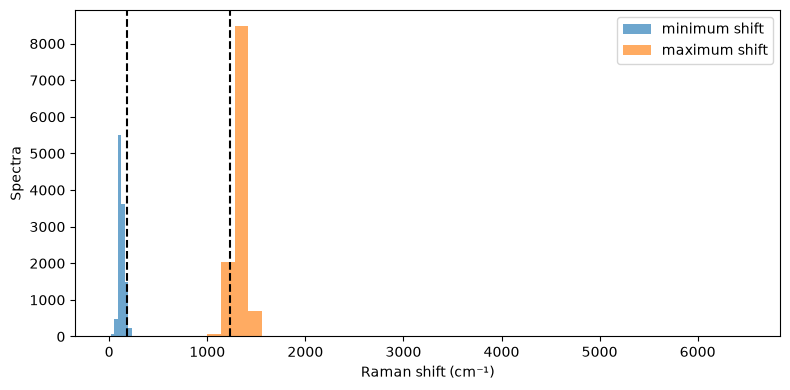

Selected interval: 180.71–1236.15 cm⁻¹
Grid: 512 points; spacing 2.065 cm⁻¹
Spectra with complete coverage: 10299


In [5]:
ok = manifest[manifest["accepted_parse"]].copy()
LOWER_LIMIT = float(np.quantile(ok["min_shift"], COVERAGE_FRACTION))
UPPER_LIMIT = float(np.quantile(ok["max_shift"], 1 - COVERAGE_FRACTION))
if LOWER_LIMIT >= UPPER_LIMIT:
    raise RuntimeError("No valid common Raman interval was found. Inspect the coverage plot and data files.")
target_grid = np.linspace(LOWER_LIMIT, UPPER_LIMIT, N_GRID_POINTS, dtype=np.float32)

coverage_ok = (ok["min_shift"] <= LOWER_LIMIT) & (ok["max_shift"] >= UPPER_LIMIT)
coverage_ids = set(ok.loc[coverage_ok, "spectrum_id"])
manifest["accepted_coverage"] = manifest["spectrum_id"].isin(coverage_ids)
mask = manifest["accepted_parse"] & ~manifest["accepted_coverage"]
manifest.loc[mask, "rejection_reason"] = "insufficient common-interval coverage"

plt.figure(figsize=(8, 4))
plt.hist(ok["min_shift"], bins=40, alpha=0.65, label="minimum shift")
plt.hist(ok["max_shift"], bins=40, alpha=0.65, label="maximum shift")
plt.axvline(LOWER_LIMIT, color="black", linestyle="--")
plt.axvline(UPPER_LIMIT, color="black", linestyle="--")
plt.xlabel("Raman shift (cm⁻¹)"); plt.ylabel("Spectra"); plt.legend(); plt.tight_layout(); plt.show()

print(f"Selected interval: {LOWER_LIMIT:.2f}–{UPPER_LIMIT:.2f} cm⁻¹")
print(f"Grid: {N_GRID_POINTS} points; spacing {target_grid[1]-target_grid[0]:.3f} cm⁻¹")
print("Spectra with complete coverage:", len(coverage_ids))


## Armonización, normalización y filtrado de clases

Cada espectro aceptado se interpola linealmente solo dentro de su rango medido y se normaliza por su intensidad absoluta máxima. Después se aplican los requisitos mínimos de observaciones y, cuando corresponde, de fuentes independientes. Las clases excluidas no disponen de evidencia suficiente para formar particiones evaluables de manera fiable.


In [6]:
X_list, labels, metadata_rows = [], [], []
for row in manifest[manifest["accepted_coverage"]].itertuples():
    shift, intensity = parsed[row.spectrum_id]
    interpolated = np.interp(target_grid, shift, intensity).astype(np.float32)
    scale = float(np.max(np.abs(interpolated)))
    if not np.isfinite(scale) or scale <= 1e-12:
        manifest.loc[manifest["spectrum_id"] == row.spectrum_id, "accepted_coverage"] = False
        manifest.loc[manifest["spectrum_id"] == row.spectrum_id, "rejection_reason"] = "invalid normalization divisor"
        continue
    normalized = (interpolated / scale).astype(np.float32)
    if not np.isfinite(normalized).all():
        raise AssertionError(f"Non-finite normalized values in {row.filepath}")
    X_list.append(normalized); labels.append(row.label)
    metadata_rows.append({
        "spectrum_id": row.spectrum_id, "filepath": row.filepath, "filename": row.filename,
        "label": row.label, "source_id": row.source_id, "source_id_status": row.source_id_status,
    })

X_all = np.asarray(X_list, dtype=np.float32)
metadata_all = pd.DataFrame(metadata_rows)
missing_source = metadata_all["source_id"].isna()
n_unresolved = int(missing_source.sum())
if n_unresolved:
    unresolved = metadata_all.loc[missing_source, [
        "spectrum_id", "filepath", "filename", "label", "source_id_status"
    ]].copy()
    unresolved.to_csv(RESULTS_DIR / "excluded_unresolved_source_ids.csv", index=False)
    print(f"Quarantining {n_unresolved} usable spectra without a uniquely resolved source ID.")
    display(unresolved.head(30))

if REQUIRE_RELIABLE_SOURCE_IDS:
    resolved_mask = (~missing_source).to_numpy()
    X_all = X_all[resolved_mask]
    metadata_all = metadata_all.loc[~missing_source].reset_index(drop=True)

if len(metadata_all) == 0:
    raise RuntimeError(
        "No spectra with reliable source IDs remain. Review source_id_audit.csv and "
        "excluded_unresolved_source_ids.csv; group-aware evaluation cannot run."
    )

source_label_counts = metadata_all.groupby("source_id")["label"].nunique()
colliding_sources = source_label_counts[source_label_counts > 1]
n_conflicting_sources = int(len(colliding_sources))
n_conflicting_spectra = 0
if n_conflicting_sources:
    conflict_mask = metadata_all["source_id"].isin(colliding_sources.index)
    collision_rows = metadata_all.loc[conflict_mask].copy()
    n_conflicting_spectra = int(conflict_mask.sum())
    collision_rows.to_csv(RESULTS_DIR / "source_label_conflicts.csv", index=False)
    conflict_summary = (collision_rows.groupby("source_id")
                        .agg(n_labels=("label", "nunique"),
                             labels=("label", lambda s: " | ".join(sorted(set(s)))),
                             n_spectra=("spectrum_id", "size"))
                        .reset_index().sort_values(["n_labels", "n_spectra"], ascending=False))
    conflict_summary.to_csv(RESULTS_DIR / "source_label_conflict_summary.csv", index=False)
    print(f"Quarantining {n_conflicting_spectra} spectra from {n_conflicting_sources} source IDs that map to multiple labels.")
    display(conflict_summary.head(30))
    clean_mask = (~conflict_mask).to_numpy()
    X_all = X_all[clean_mask]
    metadata_all = metadata_all.loc[~conflict_mask].reset_index(drop=True)

if len(metadata_all) == 0:
    raise RuntimeError(
        "No unambiguous source groups remain after quarantining cross-label conflicts. "
        "Review source_label_conflict_summary.csv; group-aware evaluation cannot run."
    )

class_spectrum_counts = metadata_all["label"].value_counts()
class_source_counts = metadata_all.groupby("label")["source_id"].nunique()
class_audit = pd.concat([
    class_spectrum_counts.rename("usable_spectra"),
    class_source_counts.rename("distinct_sources"),
], axis=1).fillna(0)
class_audit["retained"] = (
    (class_audit["usable_spectra"] >= MIN_CLASS_COUNT) &
    (class_audit["distinct_sources"] >= MIN_SOURCE_GROUPS)
)
class_audit["exclusion_reason"] = np.where(
    class_audit["usable_spectra"] < MIN_CLASS_COUNT, "too_few_spectra",
    np.where(class_audit["distinct_sources"] < MIN_SOURCE_GROUPS, "fewer_than_3_sources", "")
)
class_audit.to_csv(RESULTS_DIR / "class_source_audit.csv")

valid_classes = set(class_audit.index[class_audit["retained"]])
if not valid_classes:
    raise RuntimeError(
        "No mineral class has at least three unambiguous source groups after auditing. "
        "Review class_source_audit.csv; a group-aware train/validation/test experiment is not supported by these identifiers."
    )
keep = metadata_all["label"].isin(valid_classes).to_numpy()
X = X_all[keep]
metadata = metadata_all.loc[keep].reset_index(drop=True)

encoder = LabelEncoder()
y = encoder.fit_transform(metadata["label"]).astype(np.int32)
class_names = encoder.classes_
n_classes = len(class_names)
X_cnn = X[..., np.newaxis].astype(np.float32)

assert len(X_cnn) == len(y) == len(metadata)
assert X_cnn.shape == (len(X), N_GRID_POINTS, 1)
assert X_cnn.dtype == np.float32 and np.isfinite(X_cnn).all()
assert metadata["source_id"].notna().all()
assert metadata.groupby("source_id")["label"].nunique().max() == 1
assert metadata.groupby("label")["source_id"].nunique().min() >= MIN_SOURCE_GROUPS

manifest.to_csv(RESULTS_DIR / "final_manifest.csv", index=False)
pd.DataFrame({"class_index": np.arange(n_classes), "label": class_names}).to_csv(
    RESULTS_DIR / "label_mapping.csv", index=False
)

print("Usable spectra after source-aware class filtering:", len(X))
print("Usable spectra excluded for unresolved source ID:", n_unresolved)
print("Usable spectra excluded for cross-label source conflict:", n_conflicting_spectra)
print("Conflicting source IDs quarantined:", n_conflicting_sources)
print("Retained classes:", n_classes)
print("Distinct retained sources:", metadata["source_id"].nunique())
print("Excluded classes:", int((~class_audit["retained"]).sum()))
print("✓ Harmonized data and reliable source groups established")



[SOLO PANTALLA] raman_group_aware_augmented_experiment/results/excluded_unresolved_source_ids.csv | dimensiones: (978, 5)


,spectrum_id,filepath,filename,label,source_id_status
56,S000062,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__532______Raman_Data_P...,Adelite,filename_header_conflict
57,S000063,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__532______Raman_Data_R...,Adelite,filename_header_conflict
58,S000065,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__785______Raman_Data_R...,Adelite,filename_header_conflict
94,S000108,excellent_unoriented.zip::Aeschynite-(Y)__R080...,Aeschynite-(Y)__R080045__Raman__532______Raman...,Aeschynite-(Y),filename_header_conflict
95,S000109,excellent_unoriented.zip::Aeschynite-(Y)__R080...,Aeschynite-(Y)__R080045__Raman__532______Raman...,Aeschynite-(Y),filename_header_conflict
104,S000119,excellent_unoriented.zip::Afwillite__R070296__...,Afwillite__R070296__Raman__532______Raman_Data...,Afwillite,filename_header_conflict
105,S000120,excellent_unoriented.zip::Afwillite__R070296__...,Afwillite__R070296__Raman__532______Raman_Data...,Afwillite,filename_header_conflict
106,S000123,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__532______Raman_Data...,Afwillite,filename_header_conflict
107,S000124,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__532______Raman_Data...,Afwillite,filename_header_conflict
108,S000125,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__780______Raman_Data...,Afwillite,filename_header_conflict


Quarantining 978 usable spectra without a uniquely resolved source ID.


,spectrum_id,filepath,filename,label,source_id_status
56,S000062,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__532______Raman_Data_P...,Adelite,filename_header_conflict
57,S000063,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__532______Raman_Data_R...,Adelite,filename_header_conflict
58,S000065,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__785______Raman_Data_R...,Adelite,filename_header_conflict
94,S000108,excellent_unoriented.zip::Aeschynite-(Y)__R080...,Aeschynite-(Y)__R080045__Raman__532______Raman...,Aeschynite-(Y),filename_header_conflict
95,S000109,excellent_unoriented.zip::Aeschynite-(Y)__R080...,Aeschynite-(Y)__R080045__Raman__532______Raman...,Aeschynite-(Y),filename_header_conflict
104,S000119,excellent_unoriented.zip::Afwillite__R070296__...,Afwillite__R070296__Raman__532______Raman_Data...,Afwillite,filename_header_conflict
105,S000120,excellent_unoriented.zip::Afwillite__R070296__...,Afwillite__R070296__Raman__532______Raman_Data...,Afwillite,filename_header_conflict
106,S000123,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__532______Raman_Data...,Afwillite,filename_header_conflict
107,S000124,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__532______Raman_Data...,Afwillite,filename_header_conflict
108,S000125,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__780______Raman_Data...,Afwillite,filename_header_conflict



[SOLO PANTALLA] raman_group_aware_augmented_experiment/results/source_label_conflicts.csv | dimensiones: (6, 6)


...


[SOLO PANTALLA] raman_group_aware_augmented_experiment/results/final_manifest.csv | dimensiones: (11415, 14)


,spectrum_id,filepath,filename,label,accepted_parse,rejection_reason,source_id_filename,source_id_header,source_id,source_id_status,n_points,min_shift,max_shift,accepted_coverage
0,S000000,excellent_unoriented.zip::Abellaite__R250095__...,Abellaite__R250095__Raman__532______Raman_Data...,Abellaite,True,None,R250095,R250095,R250095,filename_header_agree,3209,50.00000,1301.270,True
1,S000001,excellent_unoriented.zip::Abellaite__R250095__...,Abellaite__R250095__Raman__532______Raman_Data...,Abellaite,True,None,R250095,R250095,R250095,filename_header_agree,3209,50.00000,1301.270,True
2,S000002,excellent_unoriented.zip::Abelsonite__R070007_...,Abelsonite__R070007__Raman__532______Raman_Dat...,Abelsonite,True,None,R070007,R070007,R070007,filename_header_agree,2312,153.55700,1267.727,True
3,S000003,excellent_unoriented.zip::Abelsonite__R070007_...,Abelsonite__R070007__Raman__532______Raman_Dat...,Abelsonite,True,None,R070007,R070007,R070007,filename_header_agree,2379,153.55700,1300.029,True
4,S000004,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__532______Raman_Data_...,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2367,163.43140,1304.119,True
5,S000005,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__532______Raman_Data_...,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2515,92.07813,1304.119,True
6,S000006,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__780______Raman_Data_...,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2476,91.82715,1285.066,True
7,S000007,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__780______Raman_Data_...,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2476,91.82715,1285.066,True
8,S000008,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,Actinolite,True,None,R040063,R040063,R040063,filename_header_agree,1077,139.24300,1513.235,True
9,S000009,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,Actinolite,True,None,R040063,R040063,R040063,filename_header_agree,1077,139.24300,1513.235,True



[SOLO PANTALLA] raman_group_aware_augmented_experiment/results/label_mapping.csv | dimensiones: (208, 2)


,class_index,label
0,0,Actinolite
1,1,Adamite
2,2,Aegirine
3,3,Agardite-(Y)
4,4,Albite
5,5,Alluaudite
6,6,Almandine
7,7,Alum-(K)
8,8,Andalusite
9,9,Andradite


Usable spectra after source-aware class filtering: 3441
Usable spectra excluded for unresolved source ID: 978
Usable spectra excluded for cross-label source conflict: 6
Conflicting source IDs quarantined: 2
Retained classes: 208
Distinct retained sources: 912
Excluded classes: 1543
✓ Harmonized data and reliable source groups established


## Armonización, normalización y filtrado de clases

Cada espectro aceptado se interpola linealmente solo dentro de su rango medido y se normaliza por su intensidad absoluta máxima. Después se aplican los requisitos mínimos de observaciones y, cuando corresponde, de fuentes independientes. Las clases excluidas no disponen de evidencia suficiente para formar particiones evaluables de manera fiable.


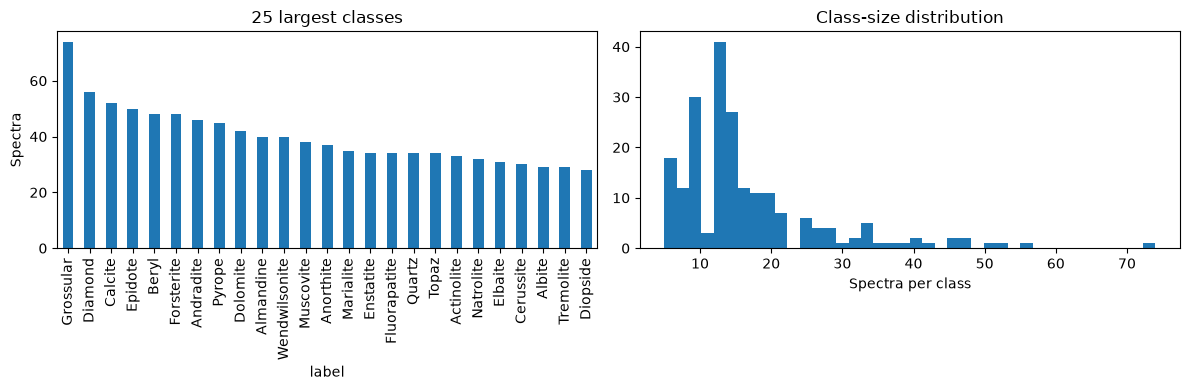

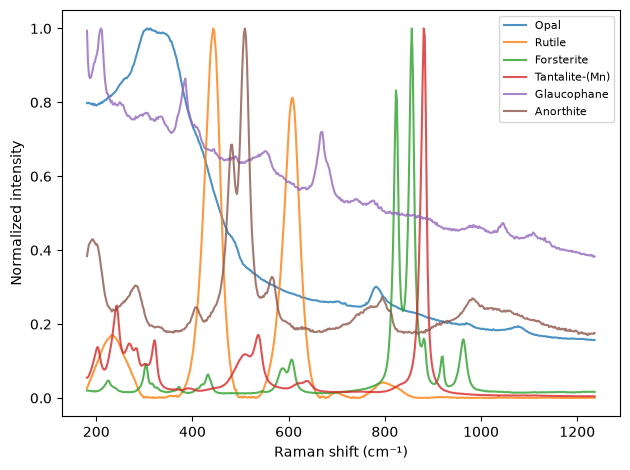

In [7]:
counts = metadata["label"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts.head(25).plot.bar(ax=axes[0]); axes[0].set_title("25 largest classes"); axes[0].set_ylabel("Spectra")
axes[1].hist(counts.values, bins=40); axes[1].set_title("Class-size distribution"); axes[1].set_xlabel("Spectra per class")
plt.tight_layout(); plt.show()

rng = np.random.default_rng(SEED)
for idx in rng.choice(len(X), size=min(6, len(X)), replace=False):
    plt.plot(target_grid, X[idx], alpha=0.8, label=metadata.loc[idx, "label"])
plt.xlabel("Raman shift (cm⁻¹)"); plt.ylabel("Normalized intensity")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()


## Construcción de entrenamiento, validación y prueba

Entrenamiento se utiliza para ajustar los pesos; validación controla la parada temprana y la selección del checkpoint; test permanece intacto hasta la evaluación final. En las versiones `group-aware`, todas las mediciones asociadas a una misma fuente RRUFF permanecen en una sola partición. Así se evita que réplicas o mediciones estrechamente relacionadas aparezcan a ambos lados de la evaluación.


In [8]:
def classwise_group_split(metadata, seed=42):
    rng = np.random.default_rng(seed)
    train_idx, val_idx, test_idx = [], [], []
    allocation_rows = []
    for label in sorted(metadata["label"].unique()):
        class_rows = metadata.index[metadata["label"] == label].to_numpy()
        sources = metadata.loc[class_rows, "source_id"].drop_duplicates().to_numpy(dtype=object)
        if len(sources) < 3:
            raise AssertionError(f"{label} has fewer than three source groups")
        rng.shuffle(sources)
        test_source, val_source = sources[0], sources[1]
        for source_id in sources:
            idx = metadata.index[(metadata["label"] == label) & (metadata["source_id"] == source_id)].to_list()
            partition = "test" if source_id == test_source else "validation" if source_id == val_source else "train"
            {"train": train_idx, "validation": val_idx, "test": test_idx}[partition].extend(idx)
            allocation_rows.append({
                "label": label, "source_id": source_id, "partition": partition,
                "n_spectra": len(idx),
            })
    arrays = tuple(np.asarray(sorted(v), dtype=np.int64) for v in (train_idx, val_idx, test_idx))
    return arrays, pd.DataFrame(allocation_rows)

(train_idx, val_idx, test_idx), source_allocation = classwise_group_split(metadata, SEED)
assert set(train_idx).isdisjoint(val_idx)
assert set(train_idx).isdisjoint(test_idx)
assert set(val_idx).isdisjoint(test_idx)
assert len(train_idx) + len(val_idx) + len(test_idx) == len(y)
assert set(np.unique(y[train_idx])) == set(np.unique(y[val_idx])) == set(np.unique(y[test_idx]))

partition_sources = {
    "train": set(metadata.iloc[train_idx]["source_id"]),
    "validation": set(metadata.iloc[val_idx]["source_id"]),
    "test": set(metadata.iloc[test_idx]["source_id"]),
}
assert partition_sources["train"].isdisjoint(partition_sources["validation"])
assert partition_sources["train"].isdisjoint(partition_sources["test"])
assert partition_sources["validation"].isdisjoint(partition_sources["test"])

X_train, y_train = X_cnn[train_idx], y[train_idx]
X_val, y_val = X_cnn[val_idx], y[val_idx]
X_test, y_test = X_cnn[test_idx], y[test_idx]

split_name = np.full(len(y), "", dtype=object)
split_name[train_idx] = "train"; split_name[val_idx] = "validation"; split_name[test_idx] = "test"
split_manifest = metadata.copy()
split_manifest["class_index"] = y
split_manifest["partition"] = split_name
split_manifest.to_csv(RESULTS_DIR / "group_aware_split_manifest.csv", index=False)
source_allocation.to_csv(RESULTS_DIR / "source_group_allocation.csv", index=False)
np.save(RESULTS_DIR / "train_indices.npy", train_idx)
np.save(RESULTS_DIR / "validation_indices.npy", val_idx)
np.save(RESULTS_DIR / "test_indices.npy", test_idx)

display(source_allocation.groupby("partition").agg(sources=("source_id", "nunique"), spectra=("n_spectra", "sum")))
print(f"Training: {len(train_idx)} | Validation: {len(val_idx)} | Test: {len(test_idx)}")
print("✓ Group-aware partitions created; no source ID crosses partitions")



[SOLO PANTALLA] raman_group_aware_augmented_experiment/results/group_aware_split_manifest.csv | dimensiones: (3441, 8)


,spectrum_id,filepath,filename,label,source_id,source_id_status,class_index,partition
0,S000008,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,Actinolite,R040063,filename_header_agree,0,train
1,S000009,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,Actinolite,R040063,filename_header_agree,0,train
2,S000010,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__532______Raman_Dat...,Actinolite,R040063,filename_header_agree,0,train
3,S000011,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__532______Raman_Dat...,Actinolite,R040063,filename_header_agree,0,train
4,S000012,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__785______Raman_Dat...,Actinolite,R040063,filename_header_agree,0,train
5,S000013,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__785______Raman_Dat...,Actinolite,R040063,filename_header_agree,0,train
6,S000014,excellent_unoriented.zip::Actinolite__R040064_...,Actinolite__R040064__Raman__514______Raman_Dat...,Actinolite,R040064,filename_header_agree,0,train
7,S000015,excellent_unoriented.zip::Actinolite__R040064_...,Actinolite__R040064__Raman__514______Raman_Dat...,Actinolite,R040064,filename_header_agree,0,train
8,S000016,excellent_unoriented.zip::Actinolite__R040064_...,Actinolite__R040064__Raman__532______Raman_Dat...,Actinolite,R040064,filename_header_agree,0,train
9,S000017,excellent_unoriented.zip::Actinolite__R040064_...,Actinolite__R040064__Raman__532______Raman_Dat...,Actinolite,R040064,filename_header_agree,0,train



[SOLO PANTALLA] raman_group_aware_augmented_experiment/results/source_group_allocation.csv | dimensiones: (912, 4)


,label,source_id,partition,n_spectra
0,Actinolite,R050336,test,6
1,Actinolite,R050025,validation,6
2,Actinolite,R120010,train,3
3,Actinolite,R060041,train,4
4,Actinolite,R040064,train,4
5,Actinolite,R060045,train,4
6,Actinolite,R040063,train,6
7,Adamite,R060593,test,4
8,Adamite,R040130,validation,4
9,Adamite,R050020,train,4



[SOLO PANTALLA] raman_group_aware_augmented_experiment/results/train_indices.npy | dimensiones: (1908, 1)


...

,0
0,10
1,11
2,12
3,13
4,14
5,15
6,33
7,34
8,35
9,36



[SOLO PANTALLA] raman_group_aware_augmented_experiment/results/test_indices.npy | dimensiones: (752, 1)


,0
0,16
1,17
2,18
3,19
4,20
5,21
6,41
7,42
8,43
9,44


,sources,spectra
partition,,
test,208,752
train,496,1908
validation,208,781


Training: 1908 | Validation: 781 | Test: 752
✓ Group-aware partitions created; no source ID crosses partitions


## Pesos de clase calculados con entrenamiento

Los pesos compensan parcialmente el desbalance, dando más importancia a clases escasas durante la optimización. Se calculan exclusivamente con las etiquetas originales de entrenamiento. Validación y test no participan en este cálculo, por lo que continúan representando datos no utilizados para ajustar el modelo.


In [9]:
weights = compute_class_weight(class_weight="balanced", classes=np.arange(n_classes), y=y_train)
class_weight_dict = {int(i): float(w) for i, w in enumerate(weights)}
(RESULTS_DIR / "class_weights.json").write_text(json.dumps(class_weight_dict, indent=2))
print("Weight range:", f"{weights.min():.3f}–{weights.max():.3f}")
print("✓ Training-only class weights calculated")


[SOLO PANTALLA] class_weights.json:
{
  "0": 0.4368131868131868,
  "1": 2.293269230769231,
  "2": 0.5096153846153846,
  "3": 1.5288461538461537,
  "4": 0.48279352226720645,
  "5": 0.833916083916084,
  "6": 0.2697963800904977,
  "7": 2.293269230769231,
  "8": 0.6552197802197802,
  "9": 0.24139676113360323,
  "10": 1.5288461538461537,
  "11": 4.586538461538462,
  "12": 0.29590570719602977,
  "13": 1.1466346153846154,
  "14": 4.586538461538462,
  "15": 4.586538461538462,
  "16": 1.5288461538461537,
  "17": 1.5288461538461537,
  "18": 0.5733173076923077,
  "19": 2.293269230769231,
  "20": 2.293269230769231,
  "21": 2.293269230769231,
  "22": 0.9173076923076923,
  "23": 1.1466346153846154,
  "24": 4.586538461538462,
  "25": 4.586538461538462,
  "26": 0.24139676113360323,
  "27": 1.1466346153846154,
  "28": 0.6552197802197802,
  "29": 0.6552197802197802,
  "30": 1.5288461538461537,
  "31": 4.586538461538462,
  "32": 2.293269230769231,
  "33": 0.2184065934065934,
  "34": 2.293269230769231,
  

## Aumento de datos exclusivo del entrenamiento

El pipeline introduce pequeñas perturbaciones compatibles con variaciones instrumentales, como desplazamientos limitados del eje y ruido moderado. Se aplica solamente al conjunto de entrenamiento. Los espectros de validación y prueba permanecen sin modificar para que las métricas correspondan a observaciones reales y comparables.


[SOLO PANTALLA] Figura mostrada; no se guarda raman_group_aware_augmented_experiment/results/augmentation_sanity_check.png


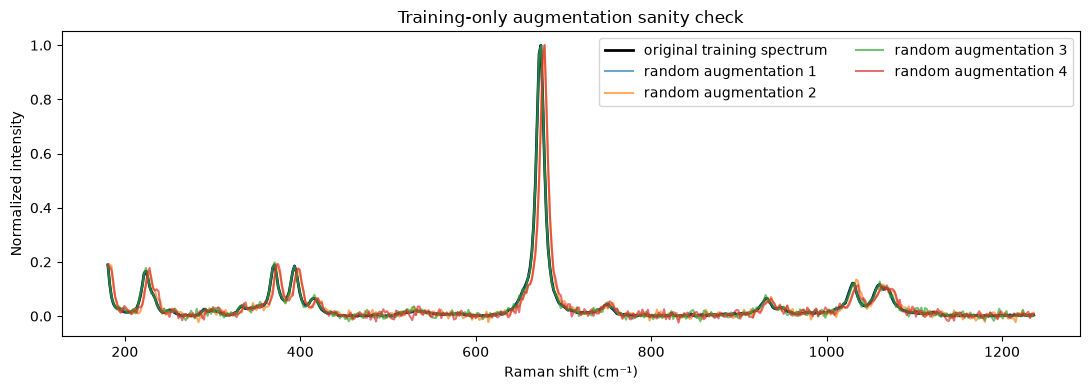

Training dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 512, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Validation and test arrays unchanged: True
✓ On-the-fly augmentation is connected only to the training pipeline


In [10]:
AUTOTUNE = tf.data.AUTOTUNE

# Immutable reference copies make accidental validation/test modification detectable.
X_val_reference = X_val.copy()
X_test_reference = X_test.copy()

def shift_with_edge_values(spectrum, shift):
    """Shift along the Raman axis without circular wrapping or zero padding."""
    n = tf.shape(spectrum)[0]
    source_positions = tf.clip_by_value(tf.range(n) - shift, 0, n - 1)
    return tf.gather(spectrum, source_positions, axis=0)

def augment_training_spectrum(spectrum, label):
    spectrum = tf.cast(spectrum, tf.float32)

    apply_shift = tf.random.uniform(()) < SHIFT_PROBABILITY
    shift = tf.random.uniform(
        (), minval=-MAX_SHIFT_POINTS, maxval=MAX_SHIFT_POINTS + 1, dtype=tf.int32
    )
    spectrum = tf.cond(
        apply_shift,
        lambda: shift_with_edge_values(spectrum, shift),
        lambda: spectrum,
    )

    apply_noise = tf.random.uniform(()) < NOISE_PROBABILITY
    noise_std = tf.random.uniform((), minval=0.0, maxval=MAX_NOISE_STD)
    spectrum = tf.cond(
        apply_noise,
        lambda: spectrum + tf.random.normal(tf.shape(spectrum), stddev=noise_std),
        lambda: spectrum,
    )

    scale = tf.maximum(tf.reduce_max(tf.abs(spectrum)), tf.constant(1e-7, tf.float32))
    spectrum = spectrum / scale
    spectrum = tf.ensure_shape(spectrum, (N_GRID_POINTS, 1))
    return spectrum, label

train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(len(X_train), seed=SEED, reshuffle_each_iteration=True)
    .map(augment_training_spectrum, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

assert np.array_equal(X_val, X_val_reference)
assert np.array_equal(X_test, X_test_reference)

# Visual sanity check: these examples are for inspection only and do not alter stored arrays.
example_index = 0
example_batch = next(iter(
    tf.data.Dataset.from_tensors((X_train[example_index], y_train[example_index]))
    .repeat(4).map(augment_training_spectrum).batch(4)
))[0].numpy()

plt.figure(figsize=(11, 4))
plt.plot(target_grid, X_train[example_index, :, 0], color="black", linewidth=2, label="original training spectrum")
for i, augmented in enumerate(example_batch):
    plt.plot(target_grid, augmented[:, 0], alpha=0.65, label=f"random augmentation {i + 1}")
plt.xlabel("Raman shift (cm⁻¹)")
plt.ylabel("Normalized intensity")
plt.title("Training-only augmentation sanity check")
plt.legend(ncol=2)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "augmentation_sanity_check.png", dpi=160)
plt.show()

print("Training dataset:", train_dataset)
print("Validation and test arrays unchanged:",
      np.array_equal(X_val, X_val_reference) and np.array_equal(X_test, X_test_reference))
print("✓ On-the-fly augmentation is connected only to the training pipeline")


## Arquitectura de la CNN 1D

La entrada es el espectro normalizado completo. Las convoluciones aprenden patrones locales asociados a picos y vecindades espectrales; el pooling reduce la resolución y el coste; las capas finales integran la información y la salida softmax asigna una probabilidad a cada clase mineral. Esta etapa conserva la arquitectura de referencia para que los cambios de rendimiento puedan atribuirse principalmente al protocolo de datos.


In [11]:
def build_model(input_shape, n_classes):
    inputs = tf.keras.Input(shape=input_shape, name="spectrum")
    x = inputs
    for filters, kernel in [(32, 11), (64, 7), (128, 5)]:
        x = tf.keras.layers.Conv1D(filters, kernel, padding="same", use_bias=False, kernel_initializer="he_normal")(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.Conv1D(256, 3, padding="same", activation="relu", kernel_initializer="he_normal")(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(256, activation="relu", kernel_initializer="he_normal")(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    outputs = tf.keras.layers.Dense(n_classes, activation="softmax", name="class_probabilities")(x)
    return tf.keras.Model(inputs, outputs, name="basic_raman_cnn")

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)
model = build_model((N_GRID_POINTS, 1), n_classes)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=min(5, n_classes), name="top_5_accuracy"),
    ],
)
assert model.output_shape[-1] == n_classes
model.summary()

sample_output = model(X_train[:2], training=False).numpy()
assert sample_output.shape == (2, n_classes)
assert np.allclose(sample_output.sum(axis=1), 1.0, atol=1e-5)
print("✓ Model and two-spectrum forward pass verified")


Model: "basic_raman_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ spectrum (InputLayer)           │ (None, 512, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 512, 32)        │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 512, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 256, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 256, 64)        │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 128, 128)       │        40,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 64, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 208)            │        53,456 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 274,352 (1.05 MB)

 Trainable params: 273,904 (1.04 MB)

 Non-trainable params: 448 (1.75 KB)

✓ Model and two-spectrum forward pass verified


## Entrenamiento del modelo

El modelo se ajusta únicamente con entrenamiento. La pérdida de validación determina la reducción de la tasa de aprendizaje, la parada temprana y la restauración del mejor checkpoint. El conjunto de prueba no se entrega a `fit` y no interviene en ninguna decisión de entrenamiento.


In [12]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True, mode="min", verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=LR_PATIENCE,
        min_lr=1e-6, mode="min", verbose=1,
    ),
]

start = time.time()
history = model.fit(
    train_dataset,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1,
)
training_minutes = (time.time() - start) / 60
print(f"✓ Training completed in {training_minutes:.1f} minutes")


/opt/anaconda3/envs/raman-cnn/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.0089 - loss: 5.4600 - top_5_accuracy: 0.0372

E0000 00:00:1786578178.520943  480273 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


60/60 ━━━━━━━━━━━━━━━━━━━━ 17s 119ms/step - accuracy: 0.0089 - loss: 5.4600 - top_5_accuracy: 0.0372 - val_accuracy: 0.0026 - val_loss: 5.3333 - val_top_5_accuracy: 0.0256 - learning_rate: 0.0010
Epoch 2/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.0225 - loss: 5.3353 - top_5_accuracy: 0.0713 - val_accuracy: 0.0102 - val_loss: 5.3155 - val_top_5_accuracy: 0.0435 - learning_rate: 0.0010
Epoch 3/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.0267 - loss: 5.2332 - top_5_accuracy: 0.0917 - val_accuracy: 0.0064 - val_loss: 5.2774 - val_top_5_accuracy: 0.0397 - learning_rate: 0.0010
Epoch 4/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.0377 - loss: 5.1244 - top_5_accuracy: 0.1190 - val_accuracy: 0.0064 - val_loss: 5.2872 - val_top_5_accuracy: 0.0461 - learning_rate: 0.0010
Epoch 5/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - accuracy: 0.0383 - loss: 5.0009 - top_5_accuracy: 0.1483 - val_accuracy: 0.0090 - val_loss: 5.1510 - val_top_5_accuracy: 0.0602 

## Curvas de aprendizaje

Las curvas permiten comparar la evolución en entrenamiento y validación. Si la pérdida de entrenamiento continúa bajando mientras la de validación aumenta, existe evidencia de sobreajuste. También ayudan a comprobar si el entrenamiento terminó por convergencia o por alcanzar el límite de épocas.


[SOLO PANTALLA] Figura mostrada; no se guarda raman_group_aware_augmented_experiment/results/learning_curves.png


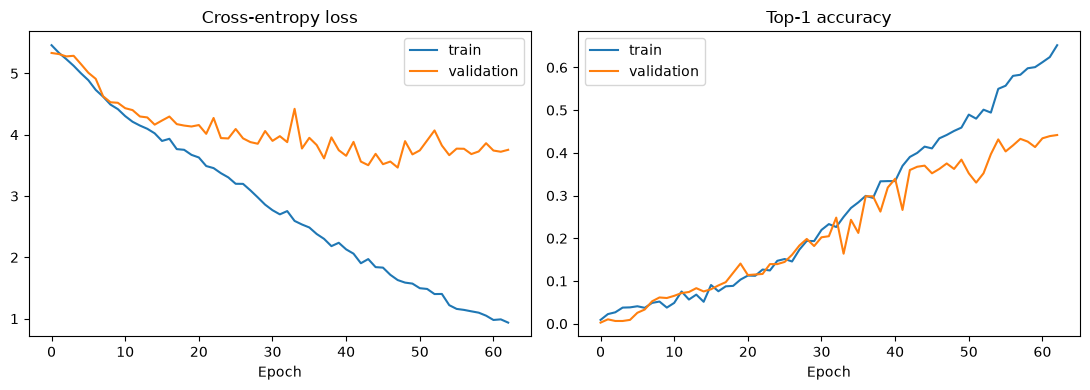

In [13]:
history_df = pd.DataFrame(history.history)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_df["loss"], label="train"); axes[0].plot(history_df["val_loss"], label="validation")
axes[0].set_title("Cross-entropy loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(history_df["accuracy"], label="train"); axes[1].plot(history_df["val_accuracy"], label="validation")
axes[1].set_title("Top-1 accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout(); plt.savefig(RESULTS_DIR / "learning_curves.png", dpi=160); plt.show()


## Evaluación final sobre test

Esta es la primera sección que utiliza el test. Top-1 exige que la clase más probable sea correcta; Top-3 y Top-5 comprueban si la clase real aparece entre las primeras alternativas. Precision, recall y F1 macro dan el mismo peso a cada mineral, mientras que sus versiones ponderadas reflejan la frecuencia de las clases. El test sirve para estimar generalización y nunca para escoger hiperparámetros.


In [14]:
test_prob = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
assert test_prob.shape == (len(test_idx), n_classes)
assert np.allclose(test_prob.sum(axis=1), 1.0, atol=1e-5)
test_pred = test_prob.argmax(axis=1)

macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    y_test, test_pred, average="macro", zero_division=0
)
weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
    y_test, test_pred, average="weighted", zero_division=0
)

metrics = {
    "test_cross_entropy": float(log_loss(y_test, test_prob, labels=np.arange(n_classes))),
    "top_1_accuracy": float(accuracy_score(y_test, test_pred)),
    "top_3_accuracy": float(top_k_accuracy_score(y_test, test_prob, k=min(3, n_classes), labels=np.arange(n_classes))),
    "top_5_accuracy": float(top_k_accuracy_score(y_test, test_prob, k=min(5, n_classes), labels=np.arange(n_classes))),
    "macro_precision": float(macro_p), "macro_recall": float(macro_r), "macro_f1": float(macro_f1),
    "weighted_precision": float(weighted_p), "weighted_recall": float(weighted_r), "weighted_f1": float(weighted_f1),
}
(RESULTS_DIR / "final_test_metrics.json").write_text(json.dumps(metrics, indent=2))
display(pd.Series(metrics, name="value").to_frame().style.format("{:.4f}"))

top_k = min(5, n_classes)
top_indices = np.argsort(-test_prob, axis=1)[:, :top_k]
predictions = split_manifest.iloc[test_idx][["spectrum_id", "filepath", "label"]].reset_index(drop=True)
predictions["predicted_label"] = class_names[test_pred]
predictions["correct"] = test_pred == y_test
predictions["top_5_labels"] = [" | ".join(class_names[row]) for row in top_indices]
predictions["top_5_probabilities"] = [" | ".join(f"{test_prob[i,j]:.5f}" for j in row) for i, row in enumerate(top_indices)]
predictions.to_csv(RESULTS_DIR / "final_test_predictions.csv", index=False)

report = pd.DataFrame(classification_report(
    y_test, test_pred, labels=np.arange(n_classes), target_names=class_names,
    zero_division=0, output_dict=True,
)).T
report.to_csv(RESULTS_DIR / "classification_report.csv")
print("✓ Final test evaluated once and metrics saved")


E0000 00:00:1786578573.183795  480273 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


[SOLO PANTALLA] final_test_metrics.json:
{
  "test_cross_entropy": 3.496128797531128,
  "top_1_accuracy": 0.40558510638297873,
  "top_3_accuracy": 0.5651595744680851,
  "top_5_accuracy": 0.6343085106382979,
  "macro_precision": 0.33273882901286744,
  "macro_recall": 0.3891025641025641,
  "macro_f1": 0.3297675505113288,
  "weighted_precision": 0.37133703692879216,
  "weighted_recall": 0.40558510638297873,
  "weighted_f1": 0.35609088276485024
}


,value
test_cross_entropy,3.4961
top_1_accuracy,0.4056
top_3_accuracy,0.5652
top_5_accuracy,0.6343
macro_precision,0.3327
macro_recall,0.3891
macro_f1,0.3298
weighted_precision,0.3713
weighted_recall,0.4056
weighted_f1,0.3561



[SOLO PANTALLA] raman_group_aware_augmented_experiment/results/final_test_predictions.csv | dimensiones: (752, 7)


,spectrum_id,filepath,label,predicted_label,correct,top_5_labels,top_5_probabilities
0,S000024,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite,Lamprophyllite,False,Lamprophyllite | Eosphorite | Anorthite | Osar...,0.23889 | 0.16869 | 0.15799 | 0.13368 | 0.05904
1,S000025,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite,Langite,False,Langite | Anorthite | Eosphorite | Dravite | V...,0.07221 | 0.05926 | 0.05801 | 0.05138 | 0.05112
2,S000026,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite,Montgomeryite,False,Montgomeryite | Lamprophyllite | Anorthite | P...,0.32054 | 0.22715 | 0.12671 | 0.05716 | 0.05578
3,S000027,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite,Montgomeryite,False,Montgomeryite | Osarizawaite | Lamprophyllite ...,0.24403 | 0.11308 | 0.10449 | 0.08991 | 0.07959
4,S000028,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite,Tourmaline,False,Tourmaline | Montgomeryite | Beudantite | Mott...,0.10981 | 0.10904 | 0.09150 | 0.08502 | 0.07631
5,S000029,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite,Tourmaline,False,Tourmaline | Sincosite | Braunite | Plumbogumm...,0.15847 | 0.11629 | 0.10271 | 0.07491 | 0.06940
6,S000056,excellent_unoriented.zip::Adamite__R060593__Ra...,Adamite,Forsterite,False,Forsterite | Adamite | Pyromorphite | Phosphos...,0.39370 | 0.17897 | 0.16071 | 0.11251 | 0.03233
7,S000057,excellent_unoriented.zip::Adamite__R060593__Ra...,Adamite,Forsterite,False,Forsterite | Adamite | Phosphosiderite | Pyrom...,0.39136 | 0.18966 | 0.11867 | 0.11779 | 0.03968
8,S000058,excellent_unoriented.zip::Adamite__R060593__Ra...,Adamite,Adamite,True,Adamite | Phosphosiderite | Microcline | Albit...,0.23344 | 0.17902 | 0.08173 | 0.08164 | 0.08015
9,S000059,excellent_unoriented.zip::Adamite__R060593__Ra...,Adamite,Phosphosiderite,False,Phosphosiderite | Volborthite | Adamite | Mang...,0.32599 | 0.12953 | 0.08722 | 0.06689 | 0.04631



[SOLO PANTALLA] raman_group_aware_augmented_experiment/results/classification_report.csv | dimensiones: (211, 4)


,precision,recall,f1-score,support
Actinolite,0.000000,0.000000,0.000000,6.0
Adamite,0.500000,0.250000,0.333333,4.0
Aegirine,0.000000,0.000000,0.000000,5.0
Agardite-(Y),0.400000,1.000000,0.571429,2.0
Albite,0.285714,1.000000,0.444444,4.0
Alluaudite,0.000000,0.000000,0.000000,4.0
Almandine,0.000000,0.000000,0.000000,2.0
Alum-(K),0.500000,0.333333,0.400000,6.0
Andalusite,1.000000,0.250000,0.400000,4.0
Andradite,0.000000,0.000000,0.000000,4.0


✓ Final test evaluated once and metrics saved


## Análisis de errores y resumen del experimento

Se exportan la matriz de confusión y los pares de confusión más frecuentes, además de ejemplos de predicciones incorrectas. Con centenares de clases, una única figura completa es difícil de leer; las tablas permiten identificar minerales problemáticos y estudiar si comparten características espectrales. El resumen registra datos, particiones, configuración y métricas para facilitar comparaciones posteriores.


In [15]:
cm = confusion_matrix(y_test, test_pred, labels=np.arange(n_classes))
np.save(RESULTS_DIR / "confusion_matrix.npy", cm)

errors = predictions.loc[~predictions["correct"]].copy()
confusions = (errors.groupby(["label", "predicted_label"]).size()
              .rename("count").reset_index().sort_values("count", ascending=False))
confusions.to_csv(RESULTS_DIR / "frequent_confusions.csv", index=False)

print("Most frequent incorrect pairs:")
display(confusions.head(20))
print("Example errors:")
display(errors.head(15))

summary = {
    "archive": ZIP_FILENAME,
    "files_found": len(filepaths),
    "spectra_retained": len(X),
    "classes_retained": n_classes,
    "distinct_sources_retained": int(metadata["source_id"].nunique()),
    "unresolved_source_spectra_excluded": n_unresolved,
    "conflicting_source_ids_excluded": n_conflicting_sources,
    "cross_label_conflict_spectra_excluded": n_conflicting_spectra,
    "raman_interval_cm-1": [LOWER_LIMIT, UPPER_LIMIT],
    "grid_points": N_GRID_POINTS,
    "split": {"train": len(train_idx), "validation": len(val_idx), "test": len(test_idx)},
    "split_strategy": "class-wise group-aware split by resolved RRUFF source ID",
    "training_augmentation": {
        "type": "on-the-fly shift plus Gaussian noise",
        "max_shift_points": MAX_SHIFT_POINTS,
        "shift_probability": SHIFT_PROBABILITY,
        "max_noise_std": MAX_NOISE_STD,
        "noise_probability": NOISE_PROBABILITY,
        "validation_augmented": False,
        "test_augmented": False,
    },
    "source_groups_cross_partitions": False,
    "source_independence_scope": "independent by resolved RRUFF archive/source ID; physical-specimen independence beyond metadata is not proven",
    "epochs_run": len(history_df),
    "training_minutes": training_minutes,
    "test_metrics": metrics,
}
(RESULTS_DIR / "experiment_summary.json").write_text(json.dumps(summary, indent=2))
print("\nResults directory:", RESULTS_DIR.resolve())
print("✓ Experiment complete")



[SOLO PANTALLA] raman_group_aware_augmented_experiment/results/confusion_matrix.npy | dimensiones: (208, 208)


,0,1,2,3,4,5,6,7,8,9,...,198,199,200,201,202,203,204,205,206,207
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,4,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,1,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



[SOLO PANTALLA] raman_group_aware_augmented_experiment/results/frequent_confusions.csv | dimensiones: (294, 3)


,label,predicted_label,count
34,Axinite-(Mn),Axinite-(Fe),6
120,Hubnerite,Tantalite-(Mn),4
74,Descloizite,Cassiterite,4
56,Catapleiite,Natrojarosite,4
53,Calcite,Aragonite,4
263,Valentinite,Parabutlerite,4
44,Beryl,Dawsonite,4
160,Moissanite,Cerussite,4
100,Fluorcalciomicrolite,Wendwilsonite,4
105,Foitite,Elbaite,4


Most frequent incorrect pairs:


,label,predicted_label,count
34,Axinite-(Mn),Axinite-(Fe),6
120,Hubnerite,Tantalite-(Mn),4
74,Descloizite,Cassiterite,4
56,Catapleiite,Natrojarosite,4
53,Calcite,Aragonite,4
263,Valentinite,Parabutlerite,4
44,Beryl,Dawsonite,4
160,Moissanite,Cerussite,4
100,Fluorcalciomicrolite,Wendwilsonite,4
105,Foitite,Elbaite,4


Example errors:


,spectrum_id,filepath,label,predicted_label,correct,top_5_labels,top_5_probabilities
0,S000024,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite,Lamprophyllite,False,Lamprophyllite | Eosphorite | Anorthite | Osar...,0.23889 | 0.16869 | 0.15799 | 0.13368 | 0.05904
1,S000025,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite,Langite,False,Langite | Anorthite | Eosphorite | Dravite | V...,0.07221 | 0.05926 | 0.05801 | 0.05138 | 0.05112
2,S000026,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite,Montgomeryite,False,Montgomeryite | Lamprophyllite | Anorthite | P...,0.32054 | 0.22715 | 0.12671 | 0.05716 | 0.05578
3,S000027,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite,Montgomeryite,False,Montgomeryite | Osarizawaite | Lamprophyllite ...,0.24403 | 0.11308 | 0.10449 | 0.08991 | 0.07959
4,S000028,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite,Tourmaline,False,Tourmaline | Montgomeryite | Beudantite | Mott...,0.10981 | 0.10904 | 0.09150 | 0.08502 | 0.07631
5,S000029,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite,Tourmaline,False,Tourmaline | Sincosite | Braunite | Plumbogumm...,0.15847 | 0.11629 | 0.10271 | 0.07491 | 0.06940
6,S000056,excellent_unoriented.zip::Adamite__R060593__Ra...,Adamite,Forsterite,False,Forsterite | Adamite | Pyromorphite | Phosphos...,0.39370 | 0.17897 | 0.16071 | 0.11251 | 0.03233
7,S000057,excellent_unoriented.zip::Adamite__R060593__Ra...,Adamite,Forsterite,False,Forsterite | Adamite | Phosphosiderite | Pyrom...,0.39136 | 0.18966 | 0.11867 | 0.11779 | 0.03968
9,S000059,excellent_unoriented.zip::Adamite__R060593__Ra...,Adamite,Phosphosiderite,False,Phosphosiderite | Volborthite | Adamite | Mang...,0.32599 | 0.12953 | 0.08722 | 0.06689 | 0.04631
10,S000070,excellent_unoriented.zip::Aegirine__R040054__R...,Aegirine,Fluor-uvite,False,Fluor-uvite | Alluaudite | Elbaite | Aegirine ...,0.39522 | 0.18558 | 0.13886 | 0.09792 | 0.05562


[SOLO PANTALLA] experiment_summary.json:
{
  "archive": "excellent_unoriented.zip",
  "files_found": 11415,
  "spectra_retained": 3441,
  "classes_retained": 208,
  "distinct_sources_retained": 912,
  "unresolved_source_spectra_excluded": 978,
  "conflicting_source_ids_excluded": 2,
  "cross_label_conflict_spectra_excluded": 6,
  "raman_interval_cm-1": [
    180.709,
    1236.155
  ],
  "grid_points": 512,
  "split": {
    "train": 1908,
    "validation": 781,
    "test": 752
  },
  "split_strategy": "class-wise group-aware split by resolved RRUFF source ID",
  "training_augmentation": {
    "type": "on-the-fly shift plus Gaussian noise",
    "max_shift_points": 3,
    "shift_probability": 0.7,
    "max_noise_std": 0.01,
    "noise_probability": 0.7,
    "validation_augmented": false,
    "test_augmented": false
  },
  "source_groups_cross_partitions": false,
  "source_independence_scope": "independent by resolved RRUFF archive/source ID; physical-specimen independence beyond metadata 

## Limitaciones e interpretación

La aumentación de los datos del conjunto de entrenamiento demuestra una mejora en el performance del modelo, a continuación se procede a utilizar toda la base de datos RUUFF para el conjunto de train, testeado sobre espectros del grupo Excellent Unoriented. 